In [1]:
"""
Modèle LSTM pour la prédiction de fin d'orage — Data Battle 2026
Alternative au XGBoost : exploite la séquence temporelle brute des éclairs
plutôt que des statistiques agrégées.

Idée centrale :
  Au lieu de calculer "rate_5min, std_interarrival, ..." à un instant t,
  on donne directement au modèle la séquence des N derniers éclairs
  (amplitude, dist, azimuth, icloud, délai depuis éclair précédent).
  Le LSTM apprend lui-même les patterns de fin d'orage.

Usage :
  Ce fichier s'intègre dans xgb_storm_corrected.py.
  Les fonctions load_data, build_alerts_from_cg, get_strikes_for_alert
  sont réutilisées telles quelles.
"""


import pandas as pd
import numpy as np
import xgboost as xgb
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib
import warnings
warnings.filterwarnings('ignore')



In [2]:
# ── Paramètres globaux ────────────────────────────────────────────────────────
SEQ_LEN     = 20      # nombre de derniers éclairs dans la séquence
HORIZON_MIN = 30      # fenêtre de prédiction
FREQ_MIN    = 1       # pas de temps de la grille
N_FEATURES  = 6       # features par éclair dans la séquence (voir build_sequence)
BATCH_SIZE  = 512
EPOCHS      = 30
LR          = 1e-3
DEVICE      = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Device : {DEVICE}")

Device : mps


In [3]:
# =============================================================================
# 1. CHARGEMENT DES DONNÉES
# =============================================================================

def load_data(filepath):
    """
    Charge le fichier CSV contenant les éclairs.
    """
    df = pd.read_csv(filepath, parse_dates=['date'])
    df = df.sort_values('date').reset_index(drop=True)

    # FIX #7 : filtrer les éclairs intra-nuage de Pise en 2016
    # (système d'enregistrement différent — cf. documentation)
    mask_pise_2016_ic = (
        (df['airport'] == 'Pise') &
        (df['date'].dt.year == 2016) &
        (df['icloud'] == True)
    )
    n_filtered = mask_pise_2016_ic.sum()
    if n_filtered > 0:
        print(f"[load_data] Filtrage Pise 2016 IC : {n_filtered} éclairs supprimés.")
    df = df[~mask_pise_2016_ic].reset_index(drop=True)

    return df


# =============================================================================
# 2. CONSTRUCTION DES ALERTES À PARTIR DES ÉCLAIRS NUAGE-SOL
# =============================================================================

def build_alerts_from_cg(df, end_delay_min=30):
    """
    Crée une table des alertes à partir des éclairs nuage-sol (icloud=False)
    qui ont un airport_alert_id non nul.

    Pour chaque alerte (aéroport + airport_alert_id), on calcule :
        - start_time        : date du premier éclair nuage-sol de l'alerte
        - end_time          : date du dernier éclair nuage-sol
                              (is_last_lightning_cloud_ground=True)
        - alert_end_official: end_time + end_delay_min  (règle opérationnelle)
        - lightning_count   : nombre total d'éclairs (tous types) dans la fenêtre
        - cg_count          : nombre d'éclairs nuage-sol
    """
    cg_strikes = df[(df['icloud'] == False) & (df['airport_alert_id'].notna())].copy()
    cg_strikes['airport_alert_id'] = cg_strikes['airport_alert_id'].astype(int)

    alerts = []
    for (airport, alert_id), group in cg_strikes.groupby(['airport', 'airport_alert_id']):
        group = group.sort_values('date')
        start_time = group['date'].iloc[0]

        last_cg = group[group['is_last_lightning_cloud_ground'] == True]
        if len(last_cg) == 0:
            end_time = group['date'].iloc[-1]
        else:
            end_time = last_cg['date'].iloc[0]

        buffer = pd.Timedelta(minutes=5)
        mask = (
            (df['airport'] == airport) &
            (df['date'] >= start_time - buffer) &
            (df['date'] <= end_time + buffer)
        )
        all_in_alert = df[mask]

        alerts.append({
            'airport':            airport,
            'airport_alert_id':   alert_id,
            'start_time':         start_time,
            'end_time':           end_time,
            'alert_end_official': end_time + pd.Timedelta(minutes=end_delay_min),
            'lightning_count':    len(all_in_alert),
            'cg_count':           len(group),
        })

    return pd.DataFrame(alerts)


# =============================================================================
# 3. GÉNÉRATION DES ÉCHANTILLONS POUR UNE ALERTE
# =============================================================================

def get_strikes_for_alert(df, airport, start_time, end_time, buffer_min=5):
    """
    Récupère tous les éclairs (tous types) pour un aéroport donné entre
    start_time - buffer_min et end_time + buffer_min.
    """
    start = start_time - pd.Timedelta(minutes=buffer_min)
    end   = end_time   + pd.Timedelta(minutes=buffer_min)
    mask  = (df['airport'] == airport) & (df['date'] >= start) & (df['date'] <= end)
    return df[mask].copy().sort_values('date')


def generate_samples_for_alert(alert_df, df_full, horizon_min=30, freq_min=1, buffer_min=5):
    """
    Pour une alerte donnée (ligne de alerts_df), génère les échantillons
    temporels (un par minute de start_time à alert_end_official).

    FIX #1 : le buffer passé à get_strikes_for_alert est élargi à
              buffer_min + horizon_min pour couvrir toute la fenêtre future
              de chaque instant t de la grille, y compris les derniers instants
              proches de alert_end_official. Sans ça, les labels y sont
              faussement mis à 0 pour les ~horizon_min dernières minutes.
    """
    airport      = alert_df['airport']
    start        = alert_df['start_time']
    end_cg       = alert_df['end_time']
    end_official = alert_df['alert_end_official']

    # Buffer élargi : couvre end_cg + buffer_min + horizon_min
    strikes = get_strikes_for_alert(
        df_full, airport, start, end_cg,
        buffer_min=buffer_min + horizon_min   # ← correction
    )

    times   = pd.date_range(start, end_official, freq=f'{freq_min}min')
    samples = []

    for t in times:
        past   = strikes[strikes['date'] < t]
        future = strikes[
            (strikes['date'] >= t) &
            (strikes['date'] <  t + pd.Timedelta(minutes=horizon_min))
        ]
        y = 1 if len(future) > 0 else 0

        features = compute_features(past, t, airport)
        features['time']             = t
        features['y']                = y
        features['airport_alert_id'] = alert_df['airport_alert_id']
        samples.append(features)

    return pd.DataFrame(samples)


"""
compute_features v2 — Feature engineering enrichi
À remplacer directement dans xgb_storm_corrected.py

Nouvelles features ajoutées par rapport à v1 :
  - Décélération de l'activité (ratio taux récent / taux global)
  - Temps depuis le pic d'activité
  - Tendance amplitude (signal physique de fin d'orage)
  - Ratio IC/CG récent vs global (précurseur fort)
  - Distance récente vs historique (l'orage s'éloigne-t-il ?)
  - Concentration azimutale (orage localisé ou diffus ?)
  - std_amplitude (variabilité de l'intensité)
  - max_interarrival (le plus long silence observé)
  - Heure en minutes depuis minuit (granularité fine vs hour entier)
"""

import pandas as pd
import numpy as np


def compute_features(past_strikes, current_time, airport):
    """
    Calcule les features à partir des éclairs passés et du contexte temporel.
    VERSION 2 — feature engineering enrichi.
    """
    feat = {'airport': airport}

    # ── Contexte temporel cyclique (invariant, calculé dans tous les cas) ──
    feat['month']        = current_time.month
    feat['hour']         = current_time.hour
    feat['month_sin']    = np.sin(2 * np.pi * current_time.month / 12)
    feat['month_cos']    = np.cos(2 * np.pi * current_time.month / 12)
    feat['hour_sin']     = np.sin(2 * np.pi * current_time.hour / 24)
    feat['hour_cos']     = np.cos(2 * np.pi * current_time.hour / 24)
    # Granularité fine : minutes depuis minuit (capte mieux les cycles diurnes)
    minutes_since_midnight = current_time.hour * 60 + current_time.minute
    feat['minute_of_day_sin'] = np.sin(2 * np.pi * minutes_since_midnight / 1440)
    feat['minute_of_day_cos'] = np.cos(2 * np.pi * minutes_since_midnight / 1440)

    # ── Cas sans aucun éclair passé ────────────────────────────────────────
    if len(past_strikes) == 0:
        nan_features = [
            'time_since_last', 'time_since_last_cg', 'time_since_last_ic',
            'time_since_first', 'time_since_peak',
            'std_interarrival', 'max_interarrival',
            'mean_dist', 'trend_dist', 'dist_recent_vs_mean',
            'angular_spread', 'azimuth_concentration',
            'prop_ic', 'mean_amplitude', 'std_amplitude', 'amplitude_trend',
            'ic_ratio_trend', 'rate_ratio_5_30', 'deceleration',
        ]
        for f in nan_features:
            feat[f] = np.nan

        zero_features = [
            'strike_count_5min', 'strike_count_10min', 'strike_count_30min',
            'rate_5min', 'rate_10min', 'rate_30min',
        ]
        for f in zero_features:
            feat[f] = 0

        return feat

    # ── Features temporelles de base ──────────────────────────────────────
    last = past_strikes.iloc[-1]
    feat['time_since_last'] = (
        current_time - last['date']
    ).total_seconds() / 60.0

    last_cg = past_strikes[past_strikes['icloud'] == False]
    feat['time_since_last_cg'] = (
        (current_time - last_cg.iloc[-1]['date']).total_seconds() / 60.0
        if len(last_cg) > 0 else np.nan
    )

    last_ic = past_strikes[past_strikes['icloud'] == True]
    feat['time_since_last_ic'] = (
        (current_time - last_ic.iloc[-1]['date']).total_seconds() / 60.0
        if len(last_ic) > 0 else np.nan
    )

    feat['time_since_first'] = (
        current_time - past_strikes.iloc[0]['date']
    ).total_seconds() / 60.0

    # ── Temps depuis le PIC d'activité ────────────────────────────────────
    # On découpe en fenêtres de 5min et on trouve celle avec le plus d'éclairs
    try:
        tmp = past_strikes.set_index('date').resample('5min').size()
        if len(tmp) > 0:
            peak_time = tmp.idxmax()
            feat['time_since_peak'] = (
                current_time - peak_time
            ).total_seconds() / 60.0
        else:
            feat['time_since_peak'] = np.nan
    except Exception:
        feat['time_since_peak'] = np.nan

    # ── Comptages & taux par fenêtre ──────────────────────────────────────
    counts = {}
    for window in [5, 10, 30]:
        mask = past_strikes['date'] >= current_time - pd.Timedelta(minutes=window)
        cnt  = int(mask.sum())
        feat[f'strike_count_{window}min'] = cnt
        feat[f'rate_{window}min']         = cnt / window
        counts[window] = cnt

    # ── Décélération : pente sur les 3 fenêtres ───────────────────────────
    # rate_5min, rate entre 5 et 10, rate entre 10 et 30
    r1 = counts[5]  / 5
    r2 = (counts[10] - counts[5])  / 5
    r3 = (counts[30] - counts[10]) / 20
    feat['deceleration'] = np.polyfit([0, 1, 2], [r1, r2, r3], 1)[0]
    # valeur négative = l'activité décroît → bon signal de fin d'orage

    # ── Ratio taux récent / taux global ───────────────────────────────────
    feat['rate_ratio_5_30'] = counts[5] / (counts[30] + 1e-6)
    # proche de 0 → l'activité récente est faible par rapport au passé

    # ── Inter-arrivées ────────────────────────────────────────────────────
    if len(past_strikes) >= 2:
        intervals = (
            past_strikes['date'].diff().dt.total_seconds().dropna() / 60.0
        )
        feat['std_interarrival'] = intervals.std()
        feat['max_interarrival'] = intervals.max()
        # grand max_interarrival = long silence déjà observé → fin probable
    else:
        feat['std_interarrival'] = np.nan
        feat['max_interarrival'] = np.nan

    # ── Spatiales ─────────────────────────────────────────────────────────
    feat['mean_dist'] = past_strikes['dist'].mean()

    recent = past_strikes.tail(min(5, len(past_strikes)))
    if len(recent) >= 2:
        slope = np.polyfit(np.arange(len(recent)), recent['dist'].values, 1)[0]
        feat['trend_dist'] = slope
        # positif → éclairs de plus en plus loin → orage qui s'éloigne
    else:
        feat['trend_dist'] = 0

    # Distance récente vs historique
    feat['dist_recent_vs_mean'] = recent['dist'].mean() - past_strikes['dist'].mean()
    # positif → éclairs récents plus loin que la moyenne → orage s'éloigne

    feat['angular_spread'] = past_strikes['azimuth'].std()

    # Concentration azimutale : proche de 1 = orage très directionnel
    feat['azimuth_concentration'] = float(
        np.sqrt(
            np.cos(np.deg2rad(past_strikes['azimuth'])).mean() ** 2 +
            np.sin(np.deg2rad(past_strikes['azimuth'])).mean() ** 2
        )
    )

    # ── Physiques ─────────────────────────────────────────────────────────
    feat['prop_ic']       = past_strikes['icloud'].mean()
    feat['mean_amplitude'] = past_strikes['amplitude'].mean()
    feat['std_amplitude']  = past_strikes['amplitude'].std()

    # Tendance amplitude sur les 10 derniers éclairs
    recent10 = past_strikes.tail(min(10, len(past_strikes)))
    if len(recent10) >= 2:
        feat['amplitude_trend'] = np.polyfit(
            np.arange(len(recent10)),
            recent10['amplitude'].values,
            1
        )[0]
        # négatif → amplitude décroissante → orage qui faiblit
    else:
        feat['amplitude_trend'] = 0

    # Ratio IC/CG récent vs global
    recent_ic  = past_strikes.tail(10)['icloud'].mean()
    global_ic  = past_strikes['icloud'].mean()
    feat['ic_ratio_trend'] = recent_ic / (global_ic + 1e-6)
    # < 1 → proportion IC récente plus faible → signal de fin d'orage

    return feat


def prepare_dataset(df, alerts_df, horizon_min=30, freq_min=1, buffer_min=5):
    """
    Parcourt toutes les alertes et construit le dataset d'entraînement.
    horizon_min est transmis jusqu'à generate_samples_for_alert qui l'utilise
    à la fois pour définir la cible y ET pour élargir le buffer de récupération
    des éclairs (fix #1).
    """
    all_samples = []
    for idx, alert_row in alerts_df.iterrows():
        samples = generate_samples_for_alert(
            alert_row, df,
            horizon_min=horizon_min,
            freq_min=freq_min,
            buffer_min=buffer_min
        )
        all_samples.append(samples)
        if (idx + 1) % 10 == 0:
            print(f"Alertes traitées : {idx+1}/{len(alerts_df)}")
    return pd.concat(all_samples, ignore_index=True)


# =============================================================================
# 4. ENTRAÎNEMENT DU MODÈLE
# =============================================================================

def train_model(X_train, y_train, X_val, y_val):
    """
    Entraîne un modèle XGBoost avec early stopping (API native Booster).
    """
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval   = xgb.DMatrix(X_val,   label=y_val)

    params = {
        'objective':        'binary:logistic',
        'max_depth':        6,
        'learning_rate':    0.05,
        'subsample':        0.8,
        'colsample_bytree': 0.8,
        'eval_metric':      'logloss',
        'seed':             42,
    }

    model = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=[(dval, 'validation')],
        early_stopping_rounds=50,
        verbose_eval=100,
    )
    return model



In [4]:
# =============================================================================
# 1. CONSTRUCTION DES SÉQUENCES
# =============================================================================

def build_sequence(past_strikes, current_time, seq_len=SEQ_LEN):
    """
    Construit un tenseur de shape (seq_len, n_features) à partir des
    seq_len derniers éclairs avant current_time.

    Features par éclair (dans l'ordre) :
      0 : délai depuis l'éclair précédent (minutes) — 0 pour le premier
      1 : délai depuis current_time (minutes)
      2 : distance à l'aéroport (km)
      3 : azimuth normalisé [0, 1]
      4 : amplitude normalisée (valeur brute en kA)
      5 : type (0=CG, 1=IC)

    Si moins de seq_len éclairs disponibles, on padde avec des zéros à gauche
    (padding causal : le modèle "voit" du silence avant l'orage).
    """
    seq = np.zeros((seq_len, N_FEATURES), dtype=np.float32)

    if len(past_strikes) == 0:
        return seq

    # Prendre les seq_len derniers éclairs
    recent = past_strikes.tail(seq_len).copy().reset_index(drop=True)
    n = len(recent)

    for i, row in recent.iterrows():
        idx = seq_len - n + i  # position dans le tenseur (padding à gauche)

        # Délai depuis éclair précédent
        if i == 0:
            interarrival = 0.0
        else:
            interarrival = (
                recent.loc[i, 'date'] - recent.loc[i-1, 'date']
            ).total_seconds() / 60.0

        # Délai depuis current_time
        time_to_now = (current_time - row['date']).total_seconds() / 60.0

        seq[idx, 0] = interarrival
        seq[idx, 1] = time_to_now
        seq[idx, 2] = row['dist']
        seq[idx, 3] = row['azimuth'] / 360.0
        seq[idx, 4] = row['amplitude']
        seq[idx, 5] = float(row['icloud'])

    return seq


def generate_lstm_samples_for_alert(
    alert_df, df_full,
    horizon_min=HORIZON_MIN, freq_min=FREQ_MIN,
    buffer_min=5, seq_len=SEQ_LEN
):
    """
    Génère les échantillons LSTM pour une alerte.
    Retourne une liste de dicts {seq, y, time, airport, airport_alert_id}.
    """
    airport      = alert_df['airport']
    start        = alert_df['start_time']
    end_cg       = alert_df['end_time']
    end_official = alert_df['alert_end_official']

    # Buffer élargi (même fix que XGBoost)
    strikes = get_strikes_for_alert(
        df_full, airport, start, end_cg,
        buffer_min=buffer_min + horizon_min
    )

    times   = pd.date_range(start, end_official, freq=f'{freq_min}min')
    samples = []

    for t in times:
        past   = strikes[strikes['date'] < t]
        future = strikes[
            (strikes['date'] >= t) &
            (strikes['date'] <  t + pd.Timedelta(minutes=horizon_min))
        ]
        y   = 1 if len(future) > 0 else 0
        seq = build_sequence(past, t, seq_len=seq_len)

        samples.append({
            'seq':              seq,
            'y':                y,
            'time':             t,
            'airport':          airport,
            'airport_alert_id': alert_df['airport_alert_id'],
        })

    return samples


def prepare_lstm_dataset(df, alerts_df,
                          horizon_min=HORIZON_MIN, freq_min=FREQ_MIN,
                          buffer_min=5, seq_len=SEQ_LEN):
    """
    Parcourt toutes les alertes et construit le dataset LSTM.
    Retourne : sequences (N, seq_len, n_feat), labels (N,), meta (DataFrame)
    """
    all_seqs   = []
    all_labels = []
    all_meta   = []

    for idx, alert_row in alerts_df.iterrows():
        samples = generate_lstm_samples_for_alert(
            alert_row, df,
            horizon_min=horizon_min,
            freq_min=freq_min,
            buffer_min=buffer_min,
            seq_len=seq_len,
        )
        for s in samples:
            all_seqs.append(s['seq'])
            all_labels.append(s['y'])
            all_meta.append({
                'time':             s['time'],
                'airport':          s['airport'],
                'airport_alert_id': s['airport_alert_id'],
            })

        if (idx + 1) % 10 == 0:
            print(f"Alertes traitées : {idx+1}/{len(alerts_df)}")

    sequences = np.stack(all_seqs)           # (N, seq_len, n_feat)
    labels    = np.array(all_labels)         # (N,)
    meta      = pd.DataFrame(all_meta)

    return sequences, labels, meta


# =============================================================================
# 2. NORMALISATION DES FEATURES DE SÉQUENCE
# =============================================================================

def fit_scaler(sequences):
    """
    Ajuste un StandardScaler sur les features continues de la séquence.
    On normalise les colonnes : interarrival (0), time_to_now (1),
    dist (2), amplitude (4). Azimuth (3) et icloud (5) sont déjà normalisés.
    """
    # Reshape en (N*seq_len, n_feat) pour fitter
    flat = sequences.reshape(-1, N_FEATURES)
    # On ne normalise que les colonnes continues
    cols_to_scale = [0, 1, 2, 4]
    scaler = StandardScaler()
    # On crée une copie pour ne pas modifier l'original
    flat_scaled = flat.copy()
    flat_scaled[:, cols_to_scale] = scaler.fit_transform(flat[:, cols_to_scale])
    scaled = flat_scaled.reshape(sequences.shape)
    return scaled, scaler


def apply_scaler(sequences, scaler):
    cols_to_scale = [0, 1, 2, 4]
    flat = sequences.reshape(-1, N_FEATURES).copy()
    flat[:, cols_to_scale] = scaler.transform(flat[:, cols_to_scale])
    return flat.reshape(sequences.shape)


# =============================================================================
# 3. DATASET PYTORCH
# =============================================================================

class StormDataset(Dataset):
    def __init__(self, sequences, labels):
        """
        sequences : np.ndarray (N, seq_len, n_feat)
        labels    : np.ndarray (N,)
        """
        self.X = torch.tensor(sequences, dtype=torch.float32)
        self.y = torch.tensor(labels,    dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# =============================================================================
# 4. ARCHITECTURE LSTM
# =============================================================================

class StormLSTM(nn.Module):
    """
    LSTM bidirectionnel + attention simple + tête de classification.

    Architecture :
      Input  : (batch, seq_len, n_feat)
      LSTM   : 2 couches bidirectionnelles, hidden=64
      Attention : pondération des états cachés par importance
      Head   : Linear → ReLU → Dropout → Linear → Sigmoid
    """
    def __init__(
        self,
        input_size  = N_FEATURES,
        hidden_size = 64,
        num_layers  = 2,
        dropout     = 0.3,
        bidirectional = True,
    ):
        super().__init__()
        self.hidden_size   = hidden_size
        self.bidirectional = bidirectional
        self.directions    = 2 if bidirectional else 1

        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0,
            bidirectional = bidirectional,
        )

        # Couche d'attention : apprend quels instants de la séquence comptent
        self.attention = nn.Linear(hidden_size * self.directions, 1)

        self.head = nn.Sequential(
            nn.Linear(hidden_size * self.directions, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        # x : (batch, seq_len, input_size)
        lstm_out, _ = self.lstm(x)
        # lstm_out : (batch, seq_len, hidden * directions)

        # Attention
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        # attn_weights : (batch, seq_len, 1)
        context = (attn_weights * lstm_out).sum(dim=1)
        # context : (batch, hidden * directions)

        return self.head(context).squeeze(-1)


# =============================================================================
# 5. ENTRAÎNEMENT
# =============================================================================

def train_lstm(
    X_train, y_train, X_val, y_val,
    epochs     = EPOCHS,
    batch_size = BATCH_SIZE,
    lr         = LR,
    device     = DEVICE,
):
    """
    Entraîne le LSTM avec early stopping sur la val loss.
    Retourne le meilleur modèle (checkpoint).
    """
    train_ds = StormDataset(X_train, y_train)
    val_ds   = StormDataset(X_val,   y_val)

    # Gestion du déséquilibre de classes (3:1 positif:négatif)
    pos_weight = torch.tensor(
        [(y_train == 0).sum() / (y_train == 1).sum()],
        dtype=torch.float32
    ).to(device)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=0, pin_memory=(device == 'cuda'))
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=0)

    model     = StormLSTM().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=3, factor=0.5, verbose=True
    )
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # Pour BCEWithLogitsLoss, on retire le Sigmoid final du head
    # → on le remet pour la prédiction (voir predict_lstm)
    # Modification : on enlève le Sigmoid du head pour l'entraînement
    model.head[-1] = nn.Identity()

    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None

    for epoch in range(epochs):
        # ── Train ──
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss   = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_losses.append(loss.item())

        # ── Validation ──
        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss   = criterion(logits, yb)
                val_losses.append(loss.item())

        train_loss = np.mean(train_losses)
        val_loss   = np.mean(val_losses)
        scheduler.step(val_loss)

        print(
            f"Epoch {epoch+1:2d}/{epochs} | "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f}"
        )

        # Early stopping
        if val_loss < best_val_loss - 1e-4:
            best_val_loss    = val_loss
            patience_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= 7:
                print(f"Early stopping à l'epoch {epoch+1}")
                break

    # Restaurer le meilleur modèle
    model.load_state_dict(best_state)
    # Remettre le Sigmoid pour la prédiction
    model.head[-1] = nn.Sigmoid()
    model.to(device)

    return model


def predict_lstm(model, sequences, batch_size=BATCH_SIZE, device=DEVICE):
    """
    Prédit les probabilités pour un ensemble de séquences.
    """
    model.eval()
    ds     = StormDataset(sequences, np.zeros(len(sequences)))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    preds  = []

    with torch.no_grad():
        for xb, _ in loader:
            xb   = xb.to(device)
            prob = model(xb)
            preds.extend(prob.cpu().numpy())

    return np.array(preds)




In [5]:
def get_last_strike_for_alert(alert_row, df_full, buffer_min=5, horizon_min=30):
    strikes = get_strikes_for_alert(
        df_full,
        alert_row['airport'],
        alert_row['start_time'],
        alert_row['end_time'],
        buffer_min=buffer_min + horizon_min   # ← correction
    )
    return strikes['date'].max()


# =============================================================================
# 6. PIPELINE COMPLET
# =============================================================================

print("=" * 60)
print("PIPELINE LSTM — PRÉDICTION FIN D'ORAGE")
print("=" * 60)

# ── 1. Chargement ─────────────────────────────────────────────────────
print("\n1. Chargement des données...")
df = load_data(
    '../data_train_databattle2026/segment_alerts_all_airports_train.csv'
)

# ── 2. Construction des alertes ───────────────────────────────────────
print("\n2. Construction des alertes...")
alerts = build_alerts_from_cg(df)
print(f"   {len(alerts)} alertes trouvées")

# ── 3. Split temporel (80/20) ─────────────────────────────────────────
n_train       = int(0.8 * len(alerts))
alerts_sorted = alerts.sort_values('start_time').reset_index(drop=True)
train_alerts  = alerts_sorted.iloc[:n_train]
val_alerts    = alerts_sorted.iloc[n_train:]

PIPELINE LSTM — PRÉDICTION FIN D'ORAGE

1. Chargement des données...
[load_data] Filtrage Pise 2016 IC : 19404 éclairs supprimés.

2. Construction des alertes...
   2627 alertes trouvées


In [6]:
# ── 4. Génération des séquences ───────────────────────────────────────
print("\n3. Génération des séquences d'entraînement...")
X_train_seq, y_train, meta_train = prepare_lstm_dataset(
    df, train_alerts, seq_len=SEQ_LEN
)

print("\n4. Génération des séquences de validation...")
X_val_seq, y_val, meta_val = prepare_lstm_dataset(
    df, val_alerts, seq_len=SEQ_LEN
)

print(f"\n   Train : {X_train_seq.shape}, Val : {X_val_seq.shape}")


3. Génération des séquences d'entraînement...
Alertes traitées : 10/2101
Alertes traitées : 20/2101
Alertes traitées : 30/2101
Alertes traitées : 40/2101
Alertes traitées : 50/2101
Alertes traitées : 60/2101
Alertes traitées : 70/2101
Alertes traitées : 80/2101
Alertes traitées : 90/2101
Alertes traitées : 100/2101
Alertes traitées : 110/2101
Alertes traitées : 120/2101
Alertes traitées : 130/2101
Alertes traitées : 140/2101
Alertes traitées : 150/2101
Alertes traitées : 160/2101
Alertes traitées : 170/2101
Alertes traitées : 180/2101
Alertes traitées : 190/2101
Alertes traitées : 200/2101
Alertes traitées : 210/2101
Alertes traitées : 220/2101
Alertes traitées : 230/2101
Alertes traitées : 240/2101
Alertes traitées : 250/2101
Alertes traitées : 260/2101
Alertes traitées : 270/2101
Alertes traitées : 280/2101
Alertes traitées : 290/2101
Alertes traitées : 300/2101
Alertes traitées : 310/2101
Alertes traitées : 320/2101
Alertes traitées : 330/2101
Alertes traitées : 340/2101
Alertes tr

In [7]:
# ── 5. Normalisation ──────────────────────────────────────────────────
print("\n5. Normalisation...")
X_train_scaled, scaler = fit_scaler(X_train_seq)
X_val_scaled           = apply_scaler(X_val_seq, scaler)
joblib.dump(scaler, 'scaler_lstm.pkl')

# ── 6. Entraînement ───────────────────────────────────────────────────
print(f"\n6. Entraînement LSTM sur {DEVICE}...")
model = train_lstm(X_train_scaled, y_train, X_val_scaled, y_val)
torch.save(model.state_dict(), 'modele_lstm_storm.pt')
print("   Modèle sauvegardé → modele_lstm_storm.pt")


5. Normalisation...

6. Entraînement LSTM sur mps...
Epoch  1/30 | train_loss=0.2174 | val_loss=0.1943
Epoch  2/30 | train_loss=0.1976 | val_loss=0.1949
Epoch  3/30 | train_loss=0.1957 | val_loss=0.1949
Epoch  4/30 | train_loss=0.1952 | val_loss=0.1926
Epoch  5/30 | train_loss=0.1942 | val_loss=0.1938
Epoch  6/30 | train_loss=0.1940 | val_loss=0.1922
Epoch  7/30 | train_loss=0.1931 | val_loss=0.1940
Epoch  8/30 | train_loss=0.1929 | val_loss=0.1925
Epoch  9/30 | train_loss=0.1922 | val_loss=0.1948
Epoch 10/30 | train_loss=0.1913 | val_loss=0.1953
Epoch 11/30 | train_loss=0.1898 | val_loss=0.1941
Epoch 12/30 | train_loss=0.1892 | val_loss=0.1940
Epoch 13/30 | train_loss=0.1884 | val_loss=0.1944
Early stopping à l'epoch 13
   Modèle sauvegardé → modele_lstm_storm.pt


In [8]:
# ── 7. Évaluation ─────────────────────────────────────────────────────
print("\n7. Évaluation...")
y_pred_proba = predict_lstm(model, X_val_scaled)
y_pred       = (y_pred_proba >= 0.5).astype(int)

print(f"ROC AUC : {roc_auc_score(y_val, y_pred_proba):.4f}")
print(classification_report(y_val, y_pred))




7. Évaluation...
ROC AUC : 0.9125
              precision    recall  f1-score   support

           0       0.61      0.85      0.71      8124
           1       0.94      0.82      0.88     24913

    accuracy                           0.83     33037
   macro avg       0.78      0.84      0.79     33037
weighted avg       0.86      0.83      0.84     33037



In [9]:
# ── 8. Calcul du gain opérationnel ────────────────────────────────────
print("\n8. Calcul du gain opérationnel...")

alerts['last_strike_real'] = alerts.apply(
    lambda row: get_last_strike_for_alert(row, df, buffer_min=5,
                                            horizon_min=HORIZON_MIN),
    axis=1
)

val_data         = meta_val.copy().reset_index(drop=True)
val_data['proba'] = y_pred_proba

val_data = val_data.merge(
    alerts[['airport', 'airport_alert_id',
            'last_strike_real', 'alert_end_official']],
    on=['airport', 'airport_alert_id'],
    how='left'
)

seuils    = np.arange(0.05, 0.81, 0.05)
resultats = []

for seuil in seuils:
    gains, erreurs, total, sans_levee = [], 0, 0, 0

    for (airport, alert_id), group in val_data.groupby(
        ['airport', 'airport_alert_id']
    ):
        total       += 1
        group        = group.sort_values('time')
        last_strike  = group['last_strike_real'].iloc[0]
        end_official = group['alert_end_official'].iloc[0]

        first_safe = group[group['proba'] < seuil]
        if len(first_safe) == 0:
            sans_levee += 1
            continue

        lift_time = first_safe.iloc[0]['time']

        if lift_time <= last_strike:
            erreurs += 1
        else:
            gain = (end_official - lift_time).total_seconds() / 60.0
            if gain > 0:
                gains.append(gain)
            else:
                sans_levee += 1

    resultats.append({
        'seuil':                 round(seuil, 2),
        'gain_moyen':            round(np.mean(gains), 2) if gains else 0,
        'taux_erreur':           round(erreurs / total, 4) if total > 0 else 0,
        'nb_alertes_anticipees': len(gains),
        'nb_sans_levee':         sans_levee,
        'nb_erreurs':            erreurs,
    })

import pandas as pd
df_res = pd.DataFrame(resultats)
print(df_res.to_string())




8. Calcul du gain opérationnel...
    seuil  gain_moyen  taux_erreur  nb_alertes_anticipees  nb_sans_levee  nb_erreurs
0    0.05        3.29       0.0323                    102            407          17
1    0.10        9.28       0.1825                    221            209          96
2    0.15       11.87       0.2871                    230            145         151
3    0.20       13.51       0.3726                    225            105         196
4    0.25       15.38       0.4240                    216             87         223
5    0.30       16.50       0.4886                    206             63         257
6    0.35       17.87       0.5285                    192             56         278
7    0.40       19.07       0.5817                    172             48         306
8    0.45       19.88       0.6502                    150             34         342
9    0.50       20.33       0.7091                    124             29         373
10   0.55       20.41       0.

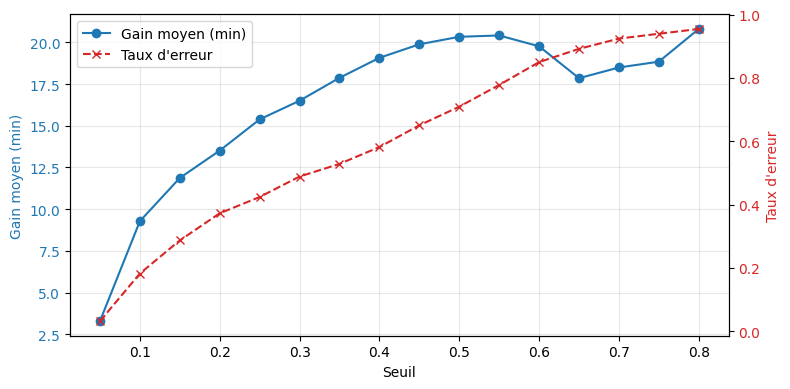


Done.


In [10]:
# ── 9. Comparaison visuelle XGBoost vs LSTM ───────────────────────────
# (décommenter si les résultats XGBoost sont disponibles dans df_xgb)
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots(figsize=(8, 4))
color1 = 'tab:blue'
ax1.plot(df_res['seuil'], df_res['gain_moyen'], 'o-', color=color1, label='Gain moyen (min)')
ax1.set_xlabel('Seuil')
ax1.set_ylabel('Gain moyen (min)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(alpha=0.3)

# Axe secondaire pour le taux d'erreur (en pourcentage)
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.plot(df_res['seuil'], df_res['taux_erreur'], 'x--', color=color2, label="Taux d'erreur")
ax2.set_ylabel("Taux d'erreur", color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
fig.tight_layout()
plt.show()

print("\nDone.")

In [12]:
# meta_val est déjà un DataFrame avec les colonnes time, airport, airport_alert_id
# Ajoutons les colonnes last_strike_real et alert_end_official depuis alerts
# On suppose que alerts est déjà chargé avec ces colonnes

val_results_lstm = meta_val.copy()
val_results_lstm['y'] = y_val
val_results_lstm['proba_lstm'] = y_pred_proba

# Ajouter les colonnes manquantes depuis alerts
val_results_lstm = val_results_lstm.merge(
    alerts[['airport', 'airport_alert_id', 'last_strike_real', 'alert_end_official']],
    on=['airport', 'airport_alert_id'],
    how='left'
)

# Sauvegarder
val_results_lstm.to_csv('val_predictions_lstm.csv', index=False)
print(f"Fichier val_predictions_lstm.csv sauvegardé avec {len(val_results_lstm)} lignes")

Fichier val_predictions_lstm.csv sauvegardé avec 33037 lignes
